**Подключаем нужные библиотеки**



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # устанавливаем seaborn по умолчанию для отрисовки графиков

**Даем доступ к диску**

In [14]:
from google.colab import drive

drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


**Читаем наш файлик**

In [15]:
train = pd.read_csv('/content/pricerunner_aggregate.csv')

**Выводим первые несколько позиций**

In [16]:
train.head()

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


**Используется набор данных https://archive.ics.uci.edu/dataset/837/product+classification+and+clustering**

**Опишем существующие поля:**

**Product ID** - уникальный числовой идентификатор товара

**Product Title** - название товара

**Merchant ID** - идентификатор продавца (?)

**Cluster ID** - идентификатор кластера, которому принадлежит товар

**Cluster Label** - название кластера

**Category ID** - идентификатор категории товара

**Category Label** - название категории

**Получаем статистику для всех числовых столбцов**

In [17]:
train.describe()

,Product ID,Merchant ID,Cluster ID,Category ID
count,35311.000000,35311.000000,35311.000000,35311.000000
mean,26150.800176,120.501883,30110.687633,2618.142930
std,13498.191220,117.045557,18410.265642,3.600708
min,1.000000,1.000000,1.000000,2612.000000
25%,14958.500000,17.000000,6123.000000,2615.000000
50%,27614.000000,75.000000,40630.000000,2619.000000
75%,37508.500000,253.000000,44059.000000,2622.000000
max,47358.000000,371.000000,47525.000000,2623.000000


Из представленных данных мы можем сделать вывод о том, что в нашем файле:
1) содержится 35311 строк
2) диапазон Product ID от 1 до 47358, показаны среднее, стандартное отклонение от среднего, квантили разной вероятности
3) количество уникальных продацов 371
4) распределение кластеров неравномерное — большинство товаров сосредоточено в небольшом числе популярных кластеров
5) среди категорий есть те, что содержат большую часть товаров

**Анализ нечисловых данных**

In [18]:
train.describe(include=['O'])

,Product Title,Cluster Label,Category Label
count,35311,35311,35311
unique,30993,12849,10
top,washing machine,Canon IXUS 185,Fridge Freezers
freq,90,27,5501


1) всего записей 35311
2) уникальных названий товаров 30993, чаще всего повторяется "стиральная машина"(90 раз)
3) уникальных кластеров 12849, 27 раз повторяется название фотоаппарата (?)
4) уникальных категорий 10, чаще всего упоминаются "холодильники с морозильником" (5501 раз)

**Узнаем информацию о полях**

In [19]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product ID       35311 non-null  int64 
 1   Product Title    35311 non-null  object
 2    Merchant ID     35311 non-null  int64 
 3    Cluster ID      35311 non-null  int64 
 4    Cluster Label   35311 non-null  object
 5    Category ID     35311 non-null  int64 
 6    Category Label  35311 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.9+ MB


**Проверяем, есть ли пропуски в наших данных**

In [20]:
train.isnull().sum()

,0
Product ID,0
Product Title,0
Merchant ID,0
Cluster ID,0
Cluster Label,0
Category ID,0
Category Label,0


как видим, пропусков нет. работая с предыдущим некорректным набором данных, я шла на радикальные меры - с помощью фильтра удаляла строки с некорректно заполненными полями, все это делалось с помощью функции train = train[train['столбец'] != 'значение']

среди моих данных нет бинарных признаков, но есть категориальные и количественные.

**Выведем зависимости с помощью графиков**

возникла проблема с названиями столбцов, выводим названия для них

In [34]:
print(train.columns.tolist())

['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label', ' Category ID', ' Category Label']


проблема была в отсутствии пробела перед навзанием поля

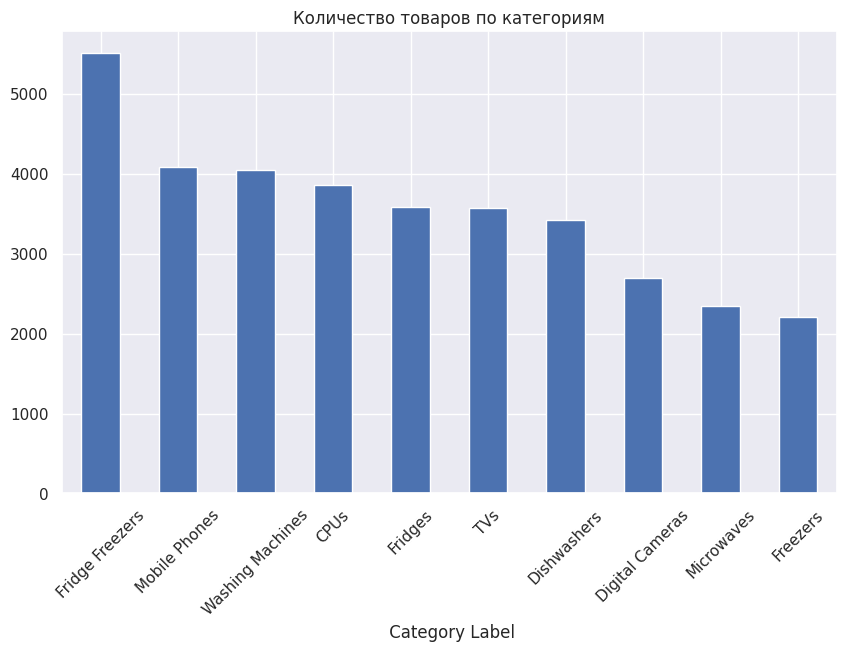

In [35]:
plt.figure(figsize=(10,6))
train[' Category Label'].value_counts().plot(kind='bar')
plt.title('Количество товаров по категориям')
plt.xticks(rotation=45)
plt.show()

мы видим распределение товаров по категориям, больше всего представлено холодильников с морозильником, меньше всего - обычных холодильников. в остальных 8 категориях представлено от 2000 до 4000+ товаров

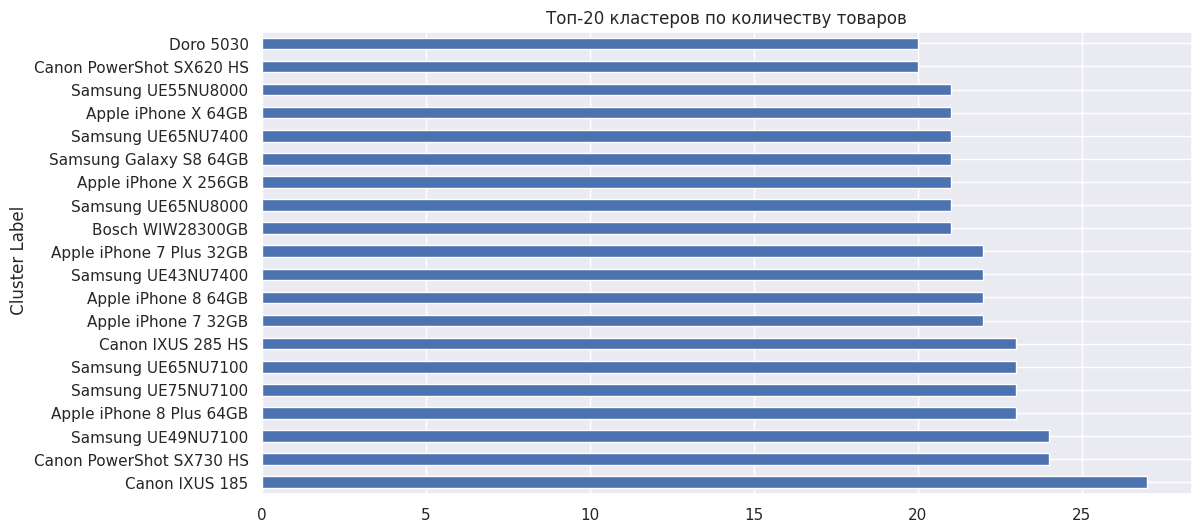

In [37]:
plt.figure(figsize=(12,6))
train[' Cluster Label'].value_counts().head(20).plot(kind='barh')
plt.title('Топ-20 кластеров по количеству товаров')
plt.show()

Выводим 20 самых больших кластеров по количеству представленных товаров, как и было сказано ранее - самое большое количество приходится на фотоаппараты определенной модели, остальные кластеры содержат в основном телефоны определенной марки

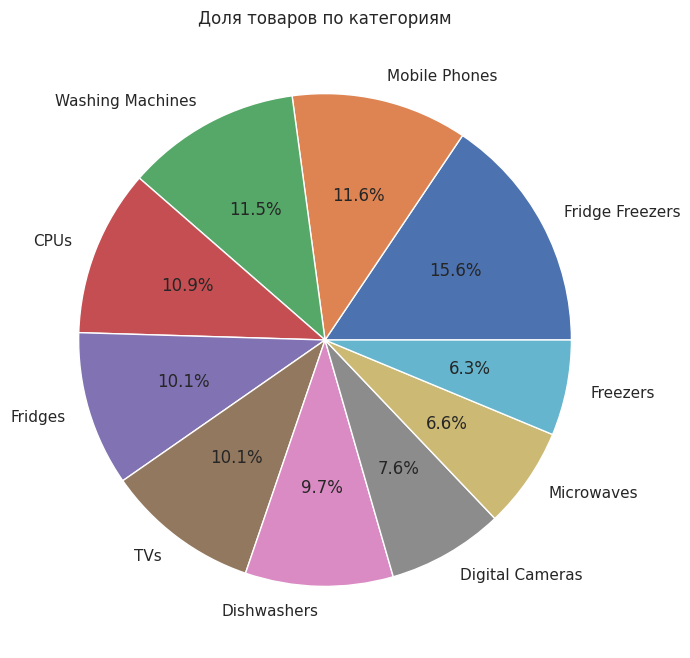

In [40]:
plt.figure(figsize=(8,8))
train[' Category Label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Доля товаров по категориям')
plt.ylabel('')
plt.show()

здесь в более удобном варианте мы можем наблюдать долю товаров, приходящуюся на определенную категорию

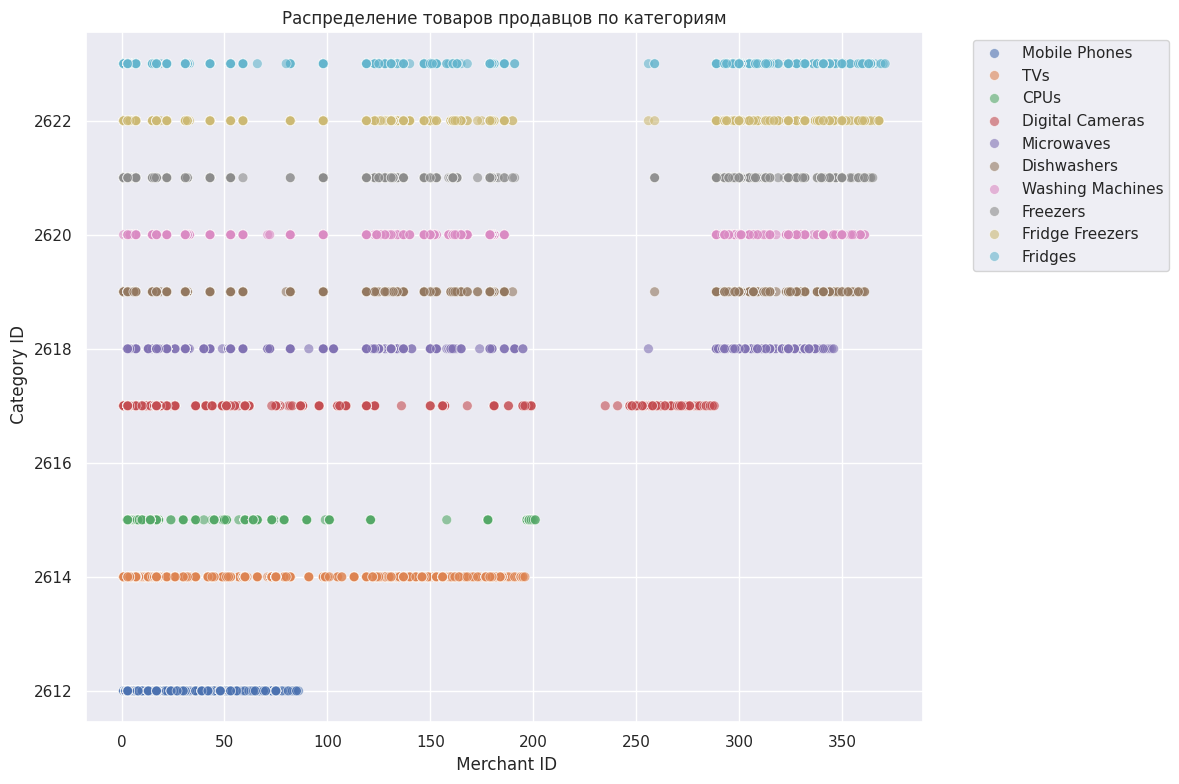

In [45]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=train, x=' Merchant ID', y=' Category ID',
                hue=' Category Label', alpha=0.6, s=50)
plt.title('Распределение товаров продавцов по категориям')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

соотношение продавцов и категорий, которые они представлят, можно увидеть, что некоторые продавцы проадют товары разных категорий, другие - одной категории

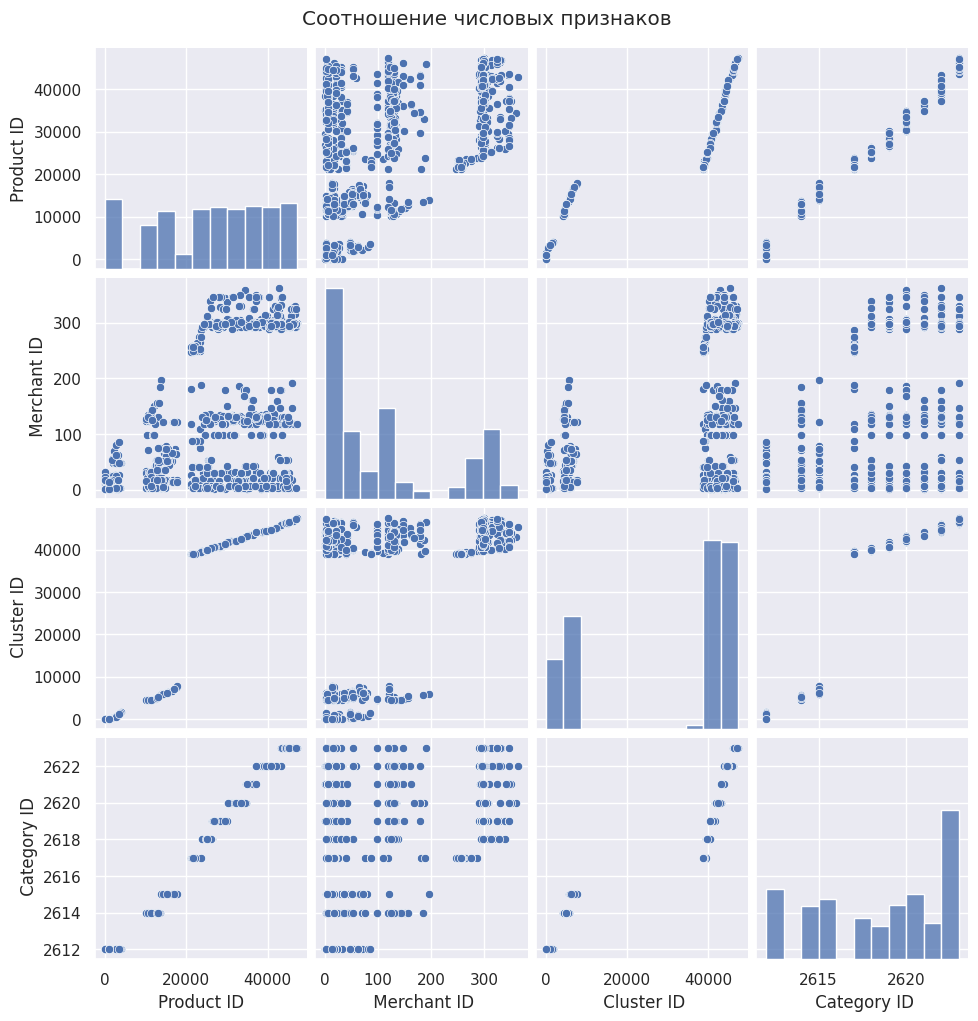

In [47]:
sns.pairplot(train[numeric_cols].sample(1000))
plt.suptitle('Соотношение числовых признаков', y=1.02)
plt.show()

соотносим все числовые признаки друг с другом, смотрим, как они коррелируют друг с другом

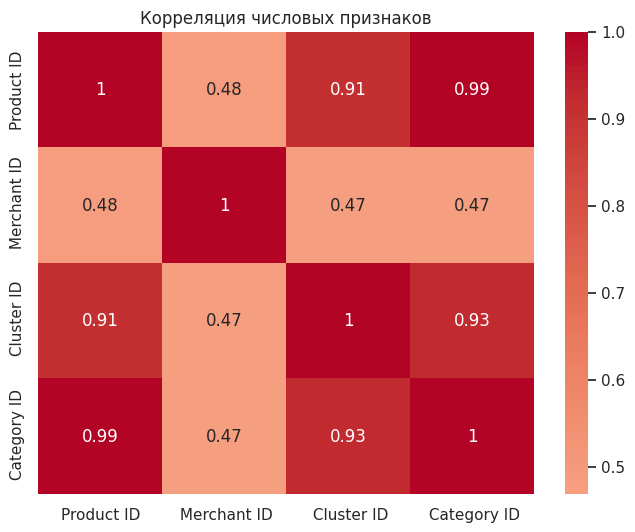

In [44]:
numeric_cols = ['Product ID', ' Merchant ID', ' Cluster ID', ' Category ID']
plt.figure(figsize=(8,6))
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

то же самое, только в виде корреляционной матрицы, как мы видим, довольно сильно друг от друга зависят идентификаторы категории и товара, идентификаторы кластера и категории и идентификаторы кластера и товара

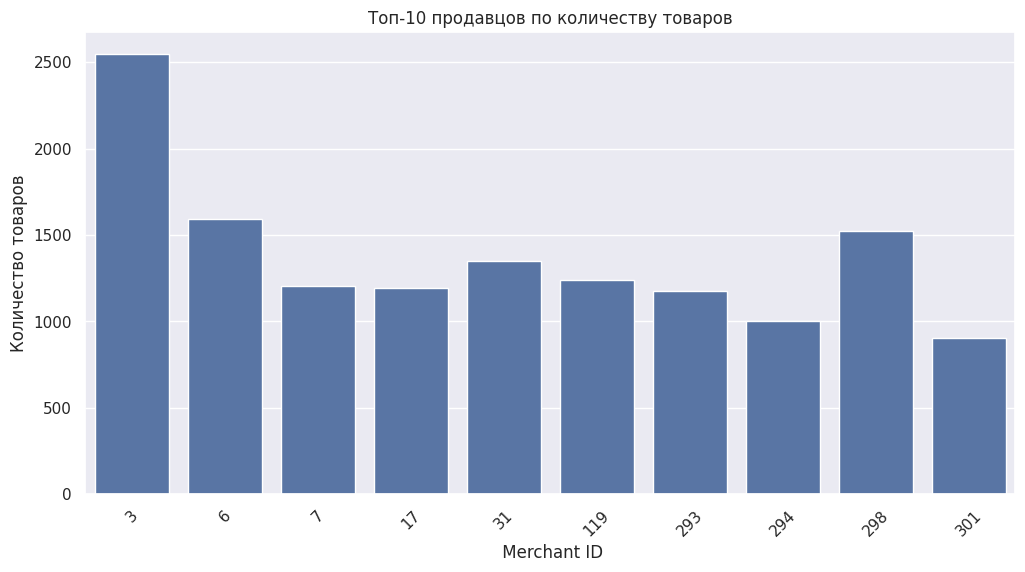

In [49]:
top_merchants = train[' Merchant ID'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_merchants.index, y=top_merchants.values)
plt.title('Топ-10 продавцов по количеству товаров')
plt.xlabel(' Merchant ID')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45)
plt.show()

здесь можно увидеть 10 идентификаторов продавцов с самым большим количсетвом представленных товаров

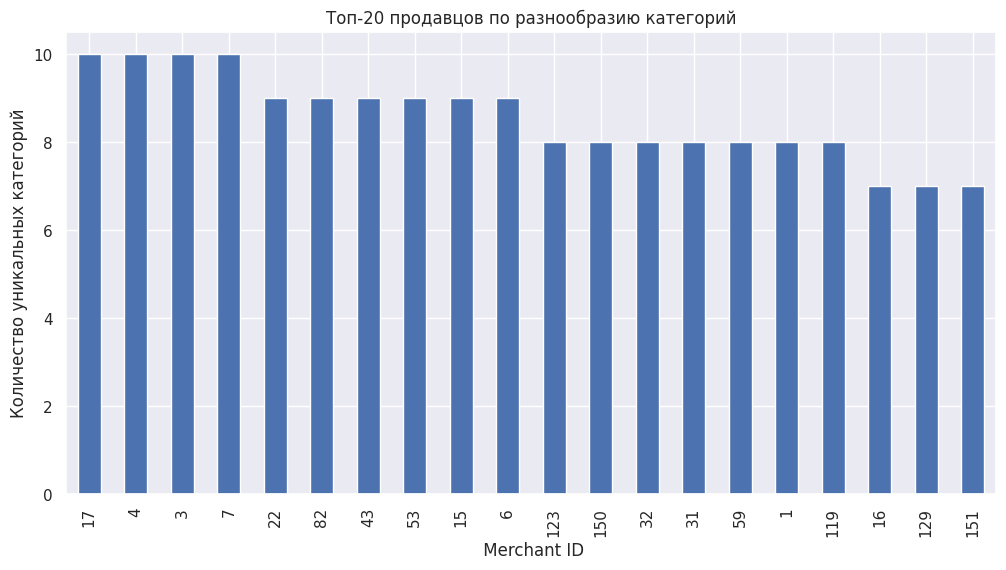

In [50]:
merchant_cats = train.groupby(' Merchant ID')[' Category Label'].nunique()
plt.figure(figsize=(12,6))
merchant_cats.sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Топ-20 продавцов по разнообразию категорий')
plt.ylabel('Количество уникальных категорий')
plt.show()

здесь представлены идентификаторы продавцов с самым большим разнообразием представленных категорий

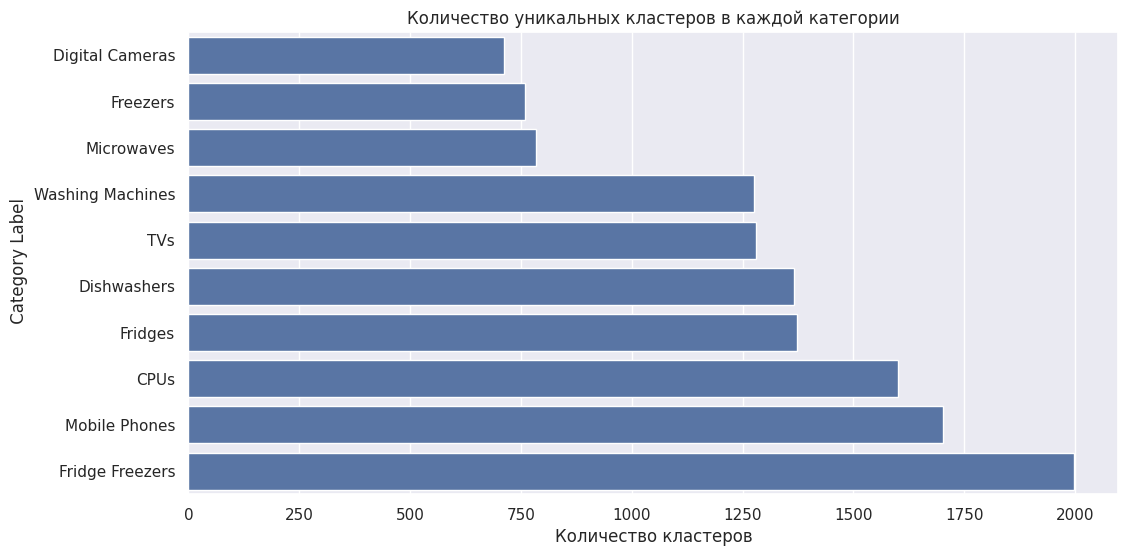

In [51]:
plt.figure(figsize=(12,6))
category_clusters = train.groupby(' Category Label')[' Cluster Label'].nunique().sort_values()
sns.barplot(x=category_clusters.values, y=category_clusters.index)
plt.title('Количество уникальных кластеров в каждой категории')
plt.xlabel('Количество кластеров')
plt.show()

здесь мы видим количество кластеров на определенную категорию

вроде, графики "красивые", без каких-то аномалий, хорошо показывают зависимость между признаками

**Напоследок попробуем преобразовать категориальные признаки в количественные**

In [52]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
train[[' Category Label']] = enc.fit_transform(train[[' Category Label']])
train.head()

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,7.0
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,7.0
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,7.0
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,7.0
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,7.0


для удобства взяла самый "маленький" категориальный признак, в нем всего 10 названий, значит, будет 10 значений